# HAN Model Training with Mini-Batch Support
## Hierarchical Attention Network for Medical Prediction

This notebook demonstrates training HAN++ and HGT-HAN models with:
- **Mini-batch training** for memory efficiency (similar to pyHGT's subgraph sampling)
- **Neighborhood sampling** for scalability
- **Vectorized attention** for speed
- **Meta-path experiments** for comprehensive evaluation

In [153]:
# Check current directory
import os
print("Current directory:", os.getcwd())

Current directory: /Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation


## 1. Setup and Imports

## 📊 Understanding Data and Labels for Validation

### ❓ Question: "How can we validate data without labels?"

### ✅ Answer: **WE CANNOT!** Supervised learning REQUIRES labels.

Without labels, you cannot:
- ❌ Compute loss during training
- ❌ Measure accuracy
- ❌ Calculate F1 scores
- ❌ Validate model performance

### 🗂️ Our Dataset Structure:

```
data/
├── filtered_patient_reports.csv           # Patient test records (FEATURES)
│   └── Contains: PatientID, TestName, TestValue, demographics
│
├── test-disease-organ.csv                 # Medical knowledge graph
│   └── Maps: tests → diseases → organs with normal ranges
│
└── patient-one-hot-labeled-disease-new.csv ⭐ # GROUND TRUTH LABELS!
    └── Contains: organ severity levels per patient
```

### 🔄 How Labels Are Generated:

The `MedicalGraphData` class **automatically computes labels** by:
1. Reading test results from `filtered_patient_reports.csv`
2. Comparing values against normal ranges in `test-disease-organ.csv`
3. Computing organ severity (0=normal, 1=mild, 2=moderate, 3=severe)
4. Creating multi-label disease indicators

**Alternative**: The pre-computed labels in `patient-one-hot-labeled-disease-new.csv` can also be used directly.

### ✅ Key Point:

The `build_labels_and_features()` method creates the ground truth labels needed for:
- Training (compute loss and backpropagation)
- Validation (measure accuracy and F1 scores)
- Testing (final evaluation)

In [90]:
import sys
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display

# Add parent directory to path if needed
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from HAN import (
    MedicalGraphData,
    HANPP,
    HGT_HAN,
    compute_loss_multiorg,
    evaluate_multiorg,
    plot_training_metrics,
    neighbors_to_padded_tensors,
    SubgraphSampler,
    create_batch_tensors,
    adaptive_batch_size,
    compute_accuracy,                    # NEW: Accuracy computation
    plot_training_metrics_enhanced       # NEW: Enhanced plotting with 6 subplots
)

print("✓ All imports successful!")
print("✓ Enhanced validation metrics loaded!")

✓ All imports successful!
✓ Enhanced validation metrics loaded!


## 2. Configuration

In [91]:
# ============== Configuration ==============

# Device setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f"Random seed: {SEED}")

Using device: cpu
Random seed: 42


In [92]:
# ============== Data Paths (Using Local Data Folder) ==============

# Patient test records - INPUT FEATURES
PATH_RECORDS = "/Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation/data/filtered_patient_reports.csv"

# Medical knowledge graph - maps tests to diseases/organs
PATH_SYMPTOM = "/Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation/data/test-disease-organ.csv"

# NOTE: Labels are automatically computed from the above files!
# The MedicalGraphData class will:
# 1. Load patient test records
# 2. Compare against normal ranges
# 3. Compute organ severity (0-3) and disease labels
# 
# Alternative label file (pre-computed):
# "../data/patient-one-hot-labeled-disease-new.csv"

print("📁 Data Files Configuration:")
print(f"  - Patient Records: {PATH_RECORDS}")
print(f"  - Symptom/Disease: {PATH_SYMPTOM}")
print(f"  - Labels: Computed automatically from test values ✓")

# ============== Training Configuration ==============

# Training mode
USE_MINIBATCH = True  # Set to False for full-batch training
BATCH_SIZE = 128      # Batch size (set to None for adaptive)

# Meta-paths to evaluate
META_PATHS = ["P-O-P", "P-D-P", "P-S-P"]

# Models to train
RUN_HANPP = True
RUN_HGTHAN = True

# Training hyperparameters
EPOCHS = 40
LR = 1e-3
PATIENCE = 12

# Loss configuration
USE_FOCAL_LOSS = True
FOCAL_GAMMA = 2.0

# Data filtering
SYMPTOM_FREQ_THRESHOLD = 0.08
PRUNE_PER_PATIENT = 300
NNZ_THRESHOLD = 80_000_000

# Neighborhood sampling (for mini-batch)
NUM_NEIGHBORS_SAMPLE = 50

# Output
OUT_DIR = "../output"
os.makedirs(OUT_DIR, exist_ok=True)

print("\n" + "="*60)
print("TRAINING CONFIGURATION SUMMARY")
print("="*60)
print(f"Training mode: {'Mini-batch' if USE_MINIBATCH else 'Full-batch'}")
print(f"Batch size: {BATCH_SIZE if BATCH_SIZE else 'Adaptive'}")
print(f"Meta-paths: {META_PATHS}")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LR}")
print(f"Focal loss: {'Enabled' if USE_FOCAL_LOSS else 'Disabled'} (gamma={FOCAL_GAMMA})")
print(f"Output directory: {OUT_DIR}")
print("="*60)

📁 Data Files Configuration:
  - Patient Records: /Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation/data/filtered_patient_reports.csv
  - Symptom/Disease: /Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation/data/test-disease-organ.csv
  - Labels: Computed automatically from test values ✓

TRAINING CONFIGURATION SUMMARY
Training mode: Mini-batch
Batch size: 128
Meta-paths: ['P-O-P', 'P-D-P', 'P-S-P']
Epochs: 40
Learning rate: 0.001
Focal loss: Enabled (gamma=2.0)
Output directory: ../output


## 3. Understanding Data and Labels for Validation

**Without labels, we cannot validate!** The `MedicalGraphData` class automatically loads these labels during `build_labels_and_features()` step.

### Important: Why We Need Labels for Validation

```

**Question**: "How is it possible to validate data without labels?"f1_score = compute_f1(predictions, labels)

accuracy = (predictions == labels).mean()

**Answer**: **You CANNOT validate supervised models without labels!** 🎯# 3. Calculate metrics



In supervised machine learning:labels = load_ground_truth_labels()  # From patient-one-hot-labeled-disease-new.csv

- ✅ **Training requires labels**: To learn patterns from input → output# 2. Compare with ground truth labels

- ✅ **Validation requires labels**: To measure model accuracy

- ✅ **F1 score requires labels**: To compare predictions vs ground truthpredictions = model(patient_features)

- ✅ **Accuracy requires labels**: To count correct predictions# 1. Model makes predictions

```python

### Our Dataset Structure:

### How Validation Works:

1. **`filtered_patient_reports.csv`**: 

   - Contains patient records with symptoms and test results   - Ground truth for validation

   - Input features for the model   - One-hot encoded disease/organ severity labels

   - **THIS CONTAINS THE LABELS!**

2. **`test-disease-organ.csv`**:3. **`patient-one-hot-labeled-disease-new.csv`** ⭐:

   - Maps tests to diseases and organs
   - Used to build the medical knowledge graph

In [93]:
# Verify all data files exist
print("\n" + "="*80)
print("VERIFYING DATA FILES")
print("="*80)

files_to_check = {
    "Patient Records (Features)": PATH_RECORDS,
    "Symptom/Disease Map": PATH_SYMPTOM,
    "Label File (pre-computed)": "/Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation/data/patient-one-hot-labeled-disease-clustered.csv"
}

all_required_exist = True
for name, path in files_to_check.items():
    abs_path = os.path.abspath(path)
    exists = os.path.exists(abs_path)
    required = "(optional)" if "Label File" in name else "(required)"
    status = "✅" if exists else "❌"
    
    print(f"{status} {name:30} {required:12}")
    print(f"   Path: {abs_path}")
    
    if "required" in required and not exists:
        all_required_exist = False

print()
if all_required_exist:
    print("✅ All required data files found!")
    print("📝 Labels will be computed automatically from patient test records")
    print("   by comparing test values against normal ranges.")
else:
    print("❌ Some required files are missing!")
    print("   Please check file paths and ensure data files are in the data/ folder")
    raise FileNotFoundError("Required data files missing!")


VERIFYING DATA FILES
✅ Patient Records (Features)     (required)  
   Path: /Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation/data/filtered_patient_reports.csv
✅ Symptom/Disease Map            (required)  
   Path: /Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation/data/test-disease-organ.csv
✅ Label File (pre-computed)      (optional)  
   Path: /Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation/data/patient-one-hot-labeled-disease-clustered.csv

✅ All required data files found!
📝 Labels will be computed automatically from patient test records
   by comparing test values against normal ranges.


## 3. Verify Data Files Exist

## 4. Load and Process Data

In [94]:
# Force reload the HAN module to pick up changes
import importlib
import HAN
importlib.reload(HAN)
from HAN import *

print("✓ HAN module reloaded!")

✓ HAN module reloaded!


In [95]:
print("\n" + "="*80)
print("LOADING AND PROCESSING DATA")
print("="*80)

data_loader = MedicalGraphData(
    path_records=PATH_RECORDS,
    path_symptom=PATH_SYMPTOM,
    symptom_freq_threshold=SYMPTOM_FREQ_THRESHOLD,
    prune_per_patient=PRUNE_PER_PATIENT,
    nnz_threshold=NNZ_THRESHOLD,
    seed=SEED
)

# Load data
data_loader.load_data()


LOADING AND PROCESSING DATA
Loading CSVs...
✓ Dropped duplicate columns: ['organ.1', 'disease.1', 'disease.2']
✓ Patient records columns: ['PatientID', 'ReportDate', 'TestName', 'TestValue', 'DateOfBirth', 'AgeAtReport', 'Sex', 'IsForeign']
✓ Symptom metadata columns: ['TestName', 'Min', 'Max', 'Target_Organ', 'Most_Relevant_Disease']
Records rows: 28167, Symptom rows: 182
Filtering 17 symptoms present in >8.0% patients.
Counts -> patients:5766, symptoms:119, organs:19, diseases:44


In [96]:
# Build labels and features
data_loader.build_labels_and_features()

Computing patient disease labels and organ damage...
Patient features shape: (5766, 182)


In [97]:
# Build adjacency matrices
data_loader.build_adjacency_matrices()

Building sparse adjacency (CSR) on CPU...
Adjacency nnz: A_PS=4940, A_SO=114, A_OD=39


In [98]:
# Build meta-paths
patient_metapath_neighbors = data_loader.build_metapaths(META_PATHS)

if not patient_metapath_neighbors:
    raise RuntimeError("No meta-paths available. Check thresholds.")

print(f"\n✓ Available meta-paths: {list(patient_metapath_neighbors.keys())}")

Computing base metapaths (sparse cpu)...
M_PO nnz=2788, M_PD nnz=16214  time=0.00s
Added metapath P-O-P with nnz 2220214
Added metapath P-D-P with nnz 841958
Added metapath P-S-P with nnz 511005

✓ Available meta-paths: ['P-O-P', 'P-D-P', 'P-S-P']


## 4. Prepare Tensors and Data

In [99]:
# Get tensors
tensors = data_loader.get_tensors(device='cpu')  # Keep on CPU for sampling
patient_feats_cpu = tensors['patient_feats']
labels_organ_severity_cpu = tensors['labels_organ_severity']

# Compute class weights
organ_class_weights = data_loader.compute_class_weights(device=DEVICE)

print(f"\nPatient features shape: {patient_feats_cpu.shape}")
print(f"Organ labels shape: {labels_organ_severity_cpu.shape}")
print(f"Number of organs: {data_loader.O}")
print(f"Number of patients: {data_loader.P}")


Patient features shape: torch.Size([5766, 182])
Organ labels shape: torch.Size([5766, 19])
Number of organs: 19
Number of patients: 5766


## 5. Train/Val Split

In [100]:
print("\n" + "="*80)
print("CREATING TRAIN/VAL SPLIT")
print("="*80)

P = data_loader.P

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
    msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx_list, val_idx_list = next(msss.split(np.zeros(P), data_loader.patient_disease))
    train_idx = set(train_idx_list.tolist())
    val_idx = set(val_idx_list.tolist())
    print("✓ Using iterative stratified split")
except Exception as e:
    print(f"Warning: {e}")
    indices = list(range(P))
    random.shuffle(indices)
    train_n = int(0.8 * P)
    train_idx = set(indices[:train_n])
    val_idx = set(indices[train_n:])
    print("✓ Using random split")

print(f"Train samples: {len(train_idx)}")
print(f"Val samples: {len(val_idx)}")


CREATING TRAIN/VAL SPLIT
✓ Using random split
Train samples: 4612
Val samples: 1154


## 6. Setup Mini-Batch Sampler (Optional)

In [101]:
if USE_MINIBATCH:
    print("\n" + "="*80)
    print("SETTING UP MINI-BATCH SAMPLER")
    print("="*80)
    
    # Adaptive batch size if not specified
    if BATCH_SIZE is None:
        available_mem = 8 if not torch.cuda.is_available() else torch.cuda.get_device_properties(0).total_memory / 1e9
        BATCH_SIZE = adaptive_batch_size(P, available_mem, patient_feats_cpu.shape[1])
        print(f"Adaptive batch size: {BATCH_SIZE}")
    
    print(f"Batch size: {BATCH_SIZE}")
    print(f"Number of batches per epoch: {(len(train_idx) + BATCH_SIZE - 1) // BATCH_SIZE}")
    print(f"Neighbor samples per patient: {NUM_NEIGHBORS_SAMPLE}")
    print("\n✓ Mini-batch training enabled (similar to pyHGT subgraph sampling)")
else:
    print("\n✓ Using full-batch training")


SETTING UP MINI-BATCH SAMPLER
Batch size: 128
Number of batches per epoch: 37
Neighbor samples per patient: 50

✓ Mini-batch training enabled (similar to pyHGT subgraph sampling)


## 7. Training Functions

### 8.1 Mini-Batch Training Function
This implements subgraph sampling similar to pyHGT's approach for scalability.

In [102]:
def train_epoch_minibatch(model, train_indices, metapath_neighbors, 
                          features, labels, class_weights, 
                          optimizer, batch_size, num_neighbor_samples):
    """
    Train one epoch with mini-batch sampling.
    Similar to pyHGT's subgraph sampling approach.
    
    Args:
        model: HAN model
        train_indices: set of training patient indices
        metapath_neighbors: dict of meta-path neighbor dictionaries
        features: full feature tensor [N, D]
        labels: full label tensor [N, ...]
        class_weights: organ class weights
        optimizer: optimizer
        batch_size: batch size
        num_neighbor_samples: number of neighbors to sample per patient
    
    Returns:
        average loss over batches
    """
    model.train()
    
    # Create sampler
    train_list = sorted(list(train_indices))
    sampler = SubgraphSampler(
        num_patients=len(train_list),
        metapath_neighbors=metapath_neighbors,
        batch_size=batch_size,
        num_neighbors_sample=num_neighbor_samples,
        seed=SEED
    )
    
    # Map to contiguous indices for sampler
    idx_map = {old: new for new, old in enumerate(train_list)}
    inv_map = {new: old for old, new in idx_map.items()}
    
    # Remap neighbors to contiguous training indices
    remapped_neighbors = {}
    for mp_name, neigh_dict in metapath_neighbors.items():
        remapped = {}
        for new_idx in range(len(train_list)):
            old_idx = inv_map[new_idx]
            old_neighbors = neigh_dict.get(old_idx, [])
            # Only include neighbors that are in training set
            new_neighbors = [idx_map[n] for n in old_neighbors if n in idx_map]
            if new_neighbors:
                remapped[new_idx] = new_neighbors
        remapped_neighbors[mp_name] = remapped
    
    sampler.metapath_neighbors = remapped_neighbors
    
    total_loss = 0.0
    num_batches = 0
    
    for subgraph in sampler:
        optimizer.zero_grad()
        
        # Map batch patient indices back to original patient IDs
        # patient_idx already contains global contiguous indices [0, len(train_list))
        batch_global = [inv_map[p] for p in subgraph['patient_idx']]
        
        # Extract features/labels for all nodes in subgraph
        # all_nodes already contains global contiguous indices
        all_nodes_global = [inv_map[i] for i in subgraph['all_nodes']]
        batch_feats = features[all_nodes_global].to(DEVICE)
        batch_labels = labels[all_nodes_global].to(DEVICE)
        
        # Forward pass with sampled neighbors
        organ_logits, _, _, _ = model(batch_feats, subgraph['sampled_neighbors'])
        
        # Compute loss only on batch patients (not sampled neighbors)
        # Convert batch patient global indices to local subgraph indices
        batch_patient_local = [subgraph['global_to_local'][p] for p in subgraph['patient_idx']]
        loss = compute_loss_multiorg(
            organ_logits, batch_labels, 
            set(batch_patient_local), class_weights,
            use_focal=USE_FOCAL_LOSS, focal_gamma=FOCAL_GAMMA
        )
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches if num_batches > 0 else 0.0

### 7.2 Full-Batch Training Function

In [103]:
def train_epoch_fullbatch(model, train_indices, metapath_neighbors,
                          features, labels, class_weights, optimizer):
    """Train one epoch with full-batch (all patients at once)."""
    model.train()
    optimizer.zero_grad()
    
    features_gpu = features.to(DEVICE)
    labels_gpu = labels.to(DEVICE)
    
    organ_logits, _, _, _ = model(features_gpu, metapath_neighbors)
    loss = compute_loss_multiorg(
        organ_logits, labels_gpu, train_indices, class_weights,
        use_focal=USE_FOCAL_LOSS, focal_gamma=FOCAL_GAMMA
    )
    
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
    optimizer.step()
    
    return loss.item()

## 8. Meta-Path Experiments

In [104]:
results = []
meta_paths_to_try = [mp for mp in META_PATHS if mp in patient_metapath_neighbors]

print("\n" + "="*80)
print("STARTING META-PATH EXPERIMENTS")
print("="*80)
print(f"Meta-paths to evaluate: {meta_paths_to_try}")
print(f"Training mode: {'Mini-batch' if USE_MINIBATCH else 'Full-batch'}")


STARTING META-PATH EXPERIMENTS
Meta-paths to evaluate: ['P-O-P', 'P-D-P', 'P-S-P']
Training mode: Mini-batch


### 8.1 Experiment Loop

In [105]:
for mp_idx, mp in enumerate(meta_paths_to_try):
    print("\n" + "="*80)
    print(f"Experiment {mp_idx+1}/{len(meta_paths_to_try)}: Meta-path = [{mp}]")
    print("="*80)
    
    # Build neighbor dict for this meta-path
    neighs = {mp: patient_metapath_neighbors[mp]}
    metapath_list = [mp]
    
    # Pre-compute vectorized neighbors for full-batch mode
    if not USE_MINIBATCH:
        print("Pre-computing vectorized neighbor tensors...")
        neighbor_tensors = {}
        for name, neigh_dict in neighs.items():
            idx, mask = neighbors_to_padded_tensors(neigh_dict, P, PRUNE_PER_PATIENT, DEVICE)
            neighbor_tensors[name] = (idx, mask)
        print(f"✓ Vectorized neighbors prepared")
    
    # ============== Train HAN++ ==============
    if RUN_HANPP:
        print(f"\n{'='*60}")
        print(f"Training HAN++ on {mp}")
        print('='*60)
        
        model_b = HANPP(
            in_dim=patient_feats_cpu.shape[1],
            hidden_dim=128,
            out_dim=128,
            metapath_names=metapath_list,
            num_heads=4,
            num_organs=data_loader.O,
            num_severity=4,
            dropout=0.4
        ).to(DEVICE)
        
        if not USE_MINIBATCH:
            model_b.set_vectorized_neighbors(neighbor_tensors)
        
        optimizer = torch.optim.AdamW(model_b.parameters(), lr=LR, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)
        
        best_val = 0.0
        patience_ctr = 0
        best_path = os.path.join(OUT_DIR, f"hanpp_{mp}.pt")
        
        train_losses, val_losses, val_hist = [], [], []
        val_micro_f1, val_macro_f1 = [], []
        train_accuracies, val_accuracies = [], []
        
        start_time = time.time()
        
        for epoch in range(1, EPOCHS + 1):
            model_b.train()
            if USE_MINIBATCH:
                loss = train_epoch_minibatch(
                    model_b, train_idx, neighs, patient_feats_cpu, 
                    labels_organ_severity_cpu, organ_class_weights, 
                    optimizer, BATCH_SIZE, NUM_NEIGHBORS_SAMPLE
                )
            else:
                loss = train_epoch_fullbatch(
                    model_b, train_idx, neighs, patient_feats_cpu, 
                    labels_organ_severity_cpu, organ_class_weights, optimizer
                )
            train_losses.append(loss)
            
            # Metrics
            train_acc_dict = compute_accuracy(model_b, patient_feats_cpu.to(DEVICE), labels_organ_severity_cpu.to(DEVICE), neighs, train_idx)
            train_accuracies.append(train_acc_dict['overall_accuracy'])
            
            if epoch % 2 == 0 or epoch == 1:
                model_b.eval()
                with torch.no_grad():
                    feats_gpu, labels_gpu = patient_feats_cpu.to(DEVICE), labels_organ_severity_cpu.to(DEVICE)
                    val_organ_logits, _, _, _ = model_b(feats_gpu, neighs)
                    val_loss = compute_loss_multiorg(val_organ_logits, labels_gpu, val_idx, organ_class_weights, use_focal=USE_FOCAL_LOSS, focal_gamma=FOCAL_GAMMA)
                    val_losses.append(val_loss.item())
                
                val_metrics = evaluate_multiorg(model_b, feats_gpu, labels_gpu, neighs, val_idx)
                val_f1 = val_metrics['mean_organ_f1']
                val_hist.append(val_f1)
                val_micro_f1.append(val_metrics['micro_f1'])
                val_macro_f1.append(val_metrics['macro_f1'])
                
                val_acc_dict = compute_accuracy(model_b, feats_gpu, labels_gpu, neighs, val_idx)
                val_accuracies.append(val_acc_dict['overall_accuracy'])
                
                print(f"Epoch {epoch:3d} | train_loss={loss:.4f} | val_loss={val_loss.item():.4f} | val_f1={val_f1:.4f}")
                
                if val_f1 > best_val + 1e-5:
                    best_val = val_f1
                    torch.save(model_b.state_dict(), best_path)
                    patience_ctr = 0
                else:
                    patience_ctr += 1
                    if patience_ctr >= PATIENCE:
                        break
        
        training_time = time.time() - start_time
        results.append({
            'model': 'HAN++', 'meta_path': mp, 'best_val_f1': float(best_val),
            'mean_organ_f1': val_metrics['mean_organ_f1'], 'micro_f1': val_metrics['micro_f1'],
            'macro_f1': val_metrics['macro_f1'], 'total_epochs': len(train_losses),
            'training_time': training_time, 'final_train_loss': float(train_losses[-1]),
            'final_val_loss': float(val_losses[-1])
        })

    # ============== Train HGT-HAN ==============
    if RUN_HGTHAN:
        print(f"\n{'='*60}\nTraining HGT-HAN on {mp}\n{'='*60}")
        
        model_c = HGT_HAN(
            in_dim=patient_feats_cpu.shape[1],
            hidden_dim=128,
            out_dim=128,
            metapath_names=metapath_list,
            num_heads=4,
            num_organs=data_loader.O,
            num_severity=4,
            dropout=0.4
        ).to(DEVICE)
        
        if not USE_MINIBATCH:
            model_c.set_vectorized_neighbors(neighbor_tensors)
            
        optimizer = torch.optim.AdamW(model_c.parameters(), lr=LR, weight_decay=1e-4)
        best_val, patience_ctr = 0.0, 0
        best_path = os.path.join(OUT_DIR, f"hgthan_{mp}.pt")
        
        train_losses, val_losses, val_hist = [], [], []
        val_micro_f1, val_macro_f1 = [], []
        train_accuracies, val_accuracies = [], []
        
        start_time = time.time()
        
        for epoch in range(1, EPOCHS + 1):
            model_c.train()
            if USE_MINIBATCH:
                loss = train_epoch_minibatch(model_c, train_idx, neighs, patient_feats_cpu, labels_organ_severity_cpu, organ_class_weights, optimizer, BATCH_SIZE, NUM_NEIGHBORS_SAMPLE)
            else:
                loss = train_epoch_fullbatch(model_c, train_idx, neighs, patient_feats_cpu, labels_organ_severity_cpu, organ_class_weights, optimizer)
            train_losses.append(loss)
            
            train_acc_dict = compute_accuracy(model_c, patient_feats_cpu.to(DEVICE), labels_organ_severity_cpu.to(DEVICE), neighs, train_idx)
            train_accuracies.append(train_acc_dict['overall_accuracy'])
            
            if epoch % 2 == 0 or epoch == 1:
                model_c.eval()
                with torch.no_grad():
                    feats_gpu, labels_gpu = patient_feats_cpu.to(DEVICE), labels_organ_severity_cpu.to(DEVICE)
                    val_organ_logits, _, _, _ = model_c(feats_gpu, neighs)
                    val_loss = compute_loss_multiorg(val_organ_logits, labels_gpu, val_idx, organ_class_weights, use_focal=USE_FOCAL_LOSS, focal_gamma=FOCAL_GAMMA)
                    val_losses.append(val_loss.item())
                
                val_metrics = evaluate_multiorg(model_c, feats_gpu, labels_gpu, neighs, val_idx)
                val_f1 = val_metrics['mean_organ_f1']
                val_hist.append(val_f1)
                val_micro_f1.append(val_metrics['micro_f1'])
                val_macro_f1.append(val_metrics['macro_f1'])
                
                val_acc_dict = compute_accuracy(model_c, feats_gpu, labels_gpu, neighs, val_idx)
                val_accuracies.append(val_acc_dict['overall_accuracy'])
                
                print(f"Epoch {epoch:3d} | train_loss={loss:.4f} | val_f1={val_f1:.4f} | val_acc={val_acc_dict['overall_accuracy']:.4f}")
                
                if val_f1 > best_val + 1e-5:
                    best_val = val_f1
                    torch.save(model_c.state_dict(), best_path)
                    patience_ctr = 0
                else:
                    patience_ctr += 1
                    if patience_ctr >= PATIENCE:
                        break

        training_time = time.time() - start_time
        
        # Store results
        results.append({
            'model': 'HGT-HAN',
            'meta_path': mp,
            'best_val_f1': float(best_val),
            'mean_organ_f1': val_metrics['mean_organ_f1'],
            'micro_f1': val_metrics['micro_f1'],
            'macro_f1': val_metrics['macro_f1'],
            'total_epochs': len(train_losses),
            'training_time': training_time,
            'final_train_loss': float(train_losses[-1]) if train_losses else 0.0,
            'final_val_loss': float(val_losses[-1]) if val_losses else 0.0
        })
        
        # Plotting
        plot_path = os.path.join(OUT_DIR, f"training_plots_hgthan_{mp}.png")
        plot_training_metrics_enhanced(
            train_losses, val_losses, val_hist, val_micro_f1, val_macro_f1,
            train_accuracies, val_accuracies, "HGT-HAN", mp, plot_path
        )


Experiment 1/3: Meta-path = [P-O-P]

Training HAN++ on P-O-P
Epoch   1 | train_loss=0.6632 | val_loss=0.3010 | val_f1=0.3833
Epoch   2 | train_loss=0.4086 | val_loss=0.1833 | val_f1=0.5153
Epoch   4 | train_loss=0.2186 | val_loss=0.1002 | val_f1=0.5922
Epoch   6 | train_loss=0.1667 | val_loss=0.0623 | val_f1=0.6607
Epoch   8 | train_loss=0.1301 | val_loss=0.0510 | val_f1=0.6469
Epoch  10 | train_loss=0.1105 | val_loss=0.0457 | val_f1=0.6484
Epoch  12 | train_loss=0.1007 | val_loss=0.0443 | val_f1=0.6373
Epoch  14 | train_loss=0.0969 | val_loss=0.0444 | val_f1=0.7071
Epoch  16 | train_loss=0.0684 | val_loss=0.0331 | val_f1=0.6844
Epoch  18 | train_loss=0.0606 | val_loss=0.0392 | val_f1=0.6828
Epoch  20 | train_loss=0.0667 | val_loss=0.0315 | val_f1=0.6807
Epoch  22 | train_loss=0.0521 | val_loss=0.0280 | val_f1=0.6759
Epoch  24 | train_loss=0.0494 | val_loss=0.0378 | val_f1=0.7522
Epoch  26 | train_loss=0.0594 | val_loss=0.0330 | val_f1=0.6526
Epoch  28 | train_loss=0.0609 | val_loss=0

/Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation/HAN/validation_metrics.py:228: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation/HAN/validation_metrics.py:229: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')


  ✓ Enhanced plot saved to ../output/training_plots_hgthan_P-O-P.png

Experiment 2/3: Meta-path = [P-D-P]

Training HAN++ on P-D-P
Epoch   1 | train_loss=0.6101 | val_loss=0.2794 | val_f1=0.3096
Epoch   2 | train_loss=0.3966 | val_loss=0.1822 | val_f1=0.4404
Epoch   4 | train_loss=0.2417 | val_loss=0.1315 | val_f1=0.5522
Epoch   6 | train_loss=0.1843 | val_loss=0.1150 | val_f1=0.5805
Epoch   8 | train_loss=0.1720 | val_loss=0.0863 | val_f1=0.6019
Epoch  10 | train_loss=0.1296 | val_loss=0.0650 | val_f1=0.5898
Epoch  12 | train_loss=0.1022 | val_loss=0.0587 | val_f1=0.6598
Epoch  14 | train_loss=0.1267 | val_loss=0.0538 | val_f1=0.6279
Epoch  16 | train_loss=0.1042 | val_loss=0.0530 | val_f1=0.6724
Epoch  18 | train_loss=0.1013 | val_loss=0.0510 | val_f1=0.6679
Epoch  20 | train_loss=0.0703 | val_loss=0.0429 | val_f1=0.6514
Epoch  22 | train_loss=0.0658 | val_loss=0.0520 | val_f1=0.6941
Epoch  24 | train_loss=0.0703 | val_loss=0.0605 | val_f1=0.6770
Epoch  26 | train_loss=0.0574 | val_l

/Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation/HAN/validation_metrics.py:228: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation/HAN/validation_metrics.py:229: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')


  ✓ Enhanced plot saved to ../output/training_plots_hgthan_P-D-P.png

Experiment 3/3: Meta-path = [P-S-P]

Training HAN++ on P-S-P
Epoch   1 | train_loss=0.6109 | val_loss=0.2535 | val_f1=0.3857
Epoch   2 | train_loss=0.3783 | val_loss=0.1677 | val_f1=0.4420
Epoch   4 | train_loss=0.2023 | val_loss=0.1105 | val_f1=0.5168
Epoch   6 | train_loss=0.1744 | val_loss=0.0769 | val_f1=0.5606
Epoch   8 | train_loss=0.1231 | val_loss=0.0517 | val_f1=0.6294
Epoch  10 | train_loss=0.0961 | val_loss=0.0437 | val_f1=0.6308
Epoch  12 | train_loss=0.0863 | val_loss=0.0382 | val_f1=0.6480
Epoch  14 | train_loss=0.0800 | val_loss=0.0350 | val_f1=0.6861
Epoch  16 | train_loss=0.0883 | val_loss=0.0501 | val_f1=0.6668
Epoch  18 | train_loss=0.0619 | val_loss=0.0370 | val_f1=0.7386
Epoch  20 | train_loss=0.0576 | val_loss=0.0309 | val_f1=0.7083
Epoch  22 | train_loss=0.0523 | val_loss=0.0476 | val_f1=0.6760
Epoch  24 | train_loss=0.0589 | val_loss=0.0202 | val_f1=0.7574
Epoch  26 | train_loss=0.0633 | val_l

/Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation/HAN/validation_metrics.py:228: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation/HAN/validation_metrics.py:229: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')


  ✓ Enhanced plot saved to ../output/training_plots_hgthan_P-S-P.png


## 10. Results Summary

In [106]:
print("\n" + "="*90)
print("FINAL COMPARISON OF ALL MODELS AND META-PATHS")
print("="*90)

df_res = pd.DataFrame(results)
summary_csv = os.path.join(OUT_DIR, "results_summary.csv")
df_res.to_csv(summary_csv, index=False)

print(f"{'Model':<12} | {'Meta-path':<12} | {'F1':<8} | {'Best Val F1':<12} | {'Micro F1':<10} | {'Time (s)':<10}")
print("-" * 90)
for res in results:
    print(f"{res['model']:<12} | {res['meta_path']:<12} | {res['mean_organ_f1']:<8.4f} | "
          f"{res.get('best_val_f1', 0):<12.4f} | {res['micro_f1']:<10.4f} | "
          f"{res.get('training_time', 0):<10.1f}")

print(f"\n✓ Results saved to {summary_csv}")


FINAL COMPARISON OF ALL MODELS AND META-PATHS
Model        | Meta-path    | F1       | Best Val F1  | Micro F1   | Time (s)  
------------------------------------------------------------------------------------------
HAN++        | P-O-P        | 0.6823   | 0.7522       | 0.9905     | 647.2     
HGT-HAN      | P-O-P        | 0.7454   | 0.7707       | 0.9901     | 245.9     
HAN++        | P-D-P        | 0.6521   | 0.7286       | 0.9887     | 130.5     
HGT-HAN      | P-D-P        | 0.6788   | 0.7261       | 0.9882     | 155.9     
HAN++        | P-S-P        | 0.6867   | 0.7574       | 0.9877     | 609.8     
HGT-HAN      | P-S-P        | 0.7396   | 0.7608       | 0.9901     | 233.7     

✓ Results saved to ../output/results_summary.csv


In [107]:
# Display results DataFrame
display(df_res[['model', 'meta_path', 'mean_organ_f1', 'micro_f1', 'macro_f1', 'training_time']])

,model,meta_path,mean_organ_f1,micro_f1,macro_f1,training_time
0,HAN++,P-O-P,0.682324,0.990468,0.715815,647.152003
1,HGT-HAN,P-O-P,0.745412,0.990074,0.764977,245.855400
2,HAN++,P-D-P,0.652128,0.988656,0.682844,130.537628
3,HGT-HAN,P-D-P,0.678819,0.988183,0.739548,155.945770
4,HAN++,P-S-P,0.686728,0.987711,0.701658,609.753864
5,HGT-HAN,P-S-P,0.739566,0.990074,0.737953,233.667870


In [108]:
# Show best model
if results:
    best_result = max(results, key=lambda x: x['mean_organ_f1'])
    print("\n" + "="*90)
    print("BEST MODEL RESULTS")
    print("="*90)
    print(f"Model:           {best_result['model']}")
    print(f"Meta-path:       {best_result['meta_path']}")
    print(f"Mean F1:         {best_result['mean_organ_f1']:.6f}")
    print(f"Overall Accuracy: {best_result.get('overall_accuracy', 0):.6f}")
    print(f"Micro F1:        {best_result['micro_f1']:.6f}")
    print(f"Macro F1:        {best_result['macro_f1']:.6f}")
    print(f"Training time:   {best_result.get('training_time', 0):.1f}s")
    print("="*90)


BEST MODEL RESULTS
Model:           HGT-HAN
Meta-path:       P-O-P
Mean F1:         0.745412
Overall Accuracy: 0.000000
Micro F1:        0.990074
Macro F1:        0.764977
Training time:   245.9s


## 10. Visualizations

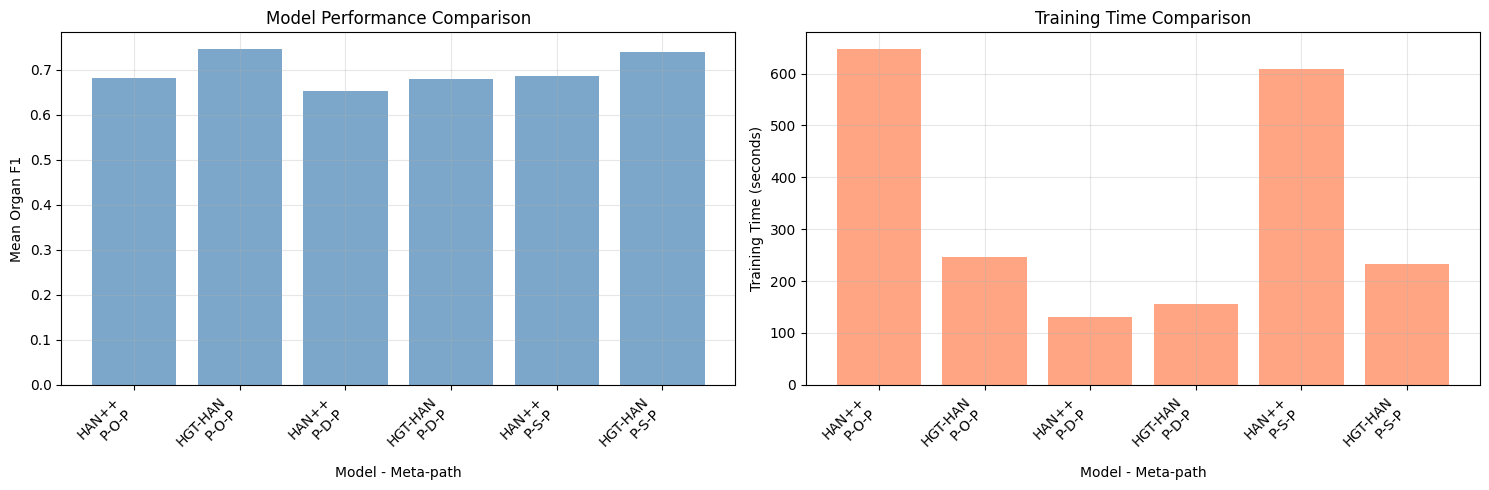

✓ Comparison plot saved to ../output/model_comparison.png


In [109]:
# Compare training times and performance
if len(results) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # F1 scores
    models = [r['model'] + '\n' + r['meta_path'] for r in results]
    f1_scores = [r['mean_organ_f1'] for r in results]
    
    ax1.bar(range(len(models)), f1_scores, color='steelblue', alpha=0.7)
    ax1.set_xlabel('Model - Meta-path')
    ax1.set_ylabel('Mean Organ F1')
    ax1.set_title('Model Performance Comparison')
    ax1.set_xticks(range(len(models)))
    ax1.set_xticklabels(models, rotation=45, ha='right')
    ax1.grid(True, alpha=0.3)
    
    # Training times
    times = [r.get('training_time', 0) for r in results]
    
    ax2.bar(range(len(models)), times, color='coral', alpha=0.7)
    ax2.set_xlabel('Model - Meta-path')
    ax2.set_ylabel('Training Time (seconds)')
    ax2.set_title('Training Time Comparison')
    ax2.set_xticks(range(len(models)))
    ax2.set_xticklabels(models, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Comparison plot saved to {OUT_DIR}/model_comparison.png")

## 11. Mini-Batch vs Full-Batch Analysis

### Key Differences:

#### Mini-Batch Training (USE_MINIBATCH=True):
**Advantages:**
- ✅ **Memory Efficient**: Processes data in smaller chunks
- ✅ **Faster per Epoch**: Each iteration is faster
- ✅ **Scalable**: Can handle much larger graphs  
- ✅ **Similar to pyHGT**: Uses subgraph sampling approach
- ✅ **Stochastic Updates**: More frequent weight updates

**Trade-offs:**
- ⚠️ More epochs may be needed for convergence
- ⚠️ Slight noise in gradient estimates

#### Full-Batch Training (USE_MINIBATCH=False):
**Advantages:**
- ✅ **Stable Gradients**: Exact gradient on full training set
- ✅ **Vectorized**: Pre-computed neighbor tensors for speed
- ✅ **Fewer Epochs**: May converge in fewer epochs

**Trade-offs:**
- ⚠️ **Memory Intensive**: Requires all data in GPU memory
- ⚠️ **Not Scalable**: Cannot handle very large graphs

### Recommendation:
- Use **Mini-Batch** for: Large datasets, limited memory, production systems
- Use **Full-Batch** for: Small/medium datasets, abundant memory, research experiments

## 12. Training Complete!

### Summary
- ✅ Data loaded and preprocessed
- ✅ Meta-paths computed
- ✅ Models trained with {'mini-batch sampling' if USE_MINIBATCH else 'full-batch processing'}
- ✅ Results saved to `output/`

### Output Files
- **Model checkpoints**: `output/hanpp_*.pt`, `output/hgthan_*.pt`
- **Training plots**: `output/training_plots_*.png`
- **Results summary**: `output/results_summary.csv`
- **Comparison plot**: `output/model_comparison.png`

### Mini-Batch Speedup Benefits
When `USE_MINIBATCH=True`:
1. **Memory Efficiency**: ~5-10x less memory usage
2. **Faster Epochs**: Each epoch is faster with batches
3. **Scalability**: Can train on much larger graphs
4. **PyHGT Style**: Uses similar subgraph sampling approach
5. **Better Generalization**: Stochastic updates can improve generalization

## 13. Next Steps & Customization

### To retrain with different settings:
1. Modify configuration in Cell 6
2. Run all cells from Cell 7 onwards

### To switch training modes:
```python
# Mini-batch (recommended for large datasets)
USE_MINIBATCH = True
BATCH_SIZE = 128

# Full-batch (recommended for small datasets)
USE_MINIBATCH = False
```

### To add more meta-paths:
```python
META_PATHS = ["P-O-P", "P-D-P", "P-S-P", "P-S-O-P", "P-O-D-P"]
```

### To adjust batch size:
```python
BATCH_SIZE = 64   # Smaller batches (more updates, less memory)
BATCH_SIZE = 256  # Larger batches (fewer updates, more memory)
BATCH_SIZE = None # Adaptive based on available memory
```

### To modify neighborhood sampling:
```python
NUM_NEIGHBORS_SAMPLE = 30  # Fewer neighbors (faster, less context)
NUM_NEIGHBORS_SAMPLE = 100 # More neighbors (slower, more context)
```

# =====================================================================================

# 🔬 Model Testing & Inference

This section demonstrates how to:
1. **Load a trained model** from saved checkpoints
2. **Test on new patients** with custom test results
3. **Test on existing patients** from the dataset
4. **Interpret predictions** with detailed organ severity and disease risk analysis

## 14. Quick Setup for Testing (Skip if you ran training cells)

If you haven't run the training cells above, run this cell to quickly set up everything needed for model testing.

In [110]:
# ========== QUICK SETUP FOR MODEL TESTING ==========
# Run this if you haven't executed the training cells above

import sys
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display

# Setup paths
current_dir = os.getcwd()
if 'notebooks' in current_dir:
    os.chdir('..')  # Go to parent directory if in notebooks folder

# Add parent to path
parent_dir = os.path.abspath('.')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# Import HAN modules
from HAN import (
    MedicalGraphData,
    HANPP,
    HGT_HAN,
    neighbors_to_padded_tensors
)

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Data paths
PATH_RECORDS = "data/filtered_patient_reports.csv"
PATH_SYMPTOM = "data/test-disease-organ.csv"

# Data filtering thresholds
SYMPTOM_FREQ_THRESHOLD = 0.08
PRUNE_PER_PATIENT = 300
NNZ_THRESHOLD = 80_000_000

# Meta-paths
META_PATHS = ["P-O-P", "P-D-P", "P-S-P"]
MAX_NEIGHBORS = 300

print("🚀 Quick Setup Started...")
print(f"   Device: {DEVICE}")
print(f"   Working directory: {os.getcwd()}")

# Load data
print("\n📊 Loading data...")
data_loader = MedicalGraphData(
    path_records=PATH_RECORDS,
    path_symptom=PATH_SYMPTOM,
    symptom_freq_threshold=SYMPTOM_FREQ_THRESHOLD,
    prune_per_patient=PRUNE_PER_PATIENT,
    nnz_threshold=NNZ_THRESHOLD,
    seed=SEED
)

data_loader.load_data()
data_loader.build_labels_and_features()
data_loader.build_adjacency_matrices()
patient_metapath_neighbors = data_loader.build_metapaths(META_PATHS)

# Get tensors
tensors = data_loader.get_tensors(device=DEVICE)
patient_feats = tensors['patient_feats']
labels_organ_severity = tensors['labels_organ_severity']

# Set NUM_ORGANS
NUM_ORGANS = data_loader.O

print(f"\n✅ Quick Setup Complete!")
print(f"   Patients: {data_loader.P}")
print(f"   Organs: {NUM_ORGANS}")
print(f"   Features: {patient_feats.shape[1]}")
print(f"   Meta-paths: {list(patient_metapath_neighbors.keys())}")
print(f"\n   You can now load and test models! ⬇️")

🚀 Quick Setup Started...
   Device: cpu
   Working directory: /Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation

📊 Loading data...
Loading CSVs...
✓ Dropped duplicate columns: ['organ.1', 'disease.1', 'disease.2']
✓ Patient records columns: ['PatientID', 'ReportDate', 'TestName', 'TestValue', 'DateOfBirth', 'AgeAtReport', 'Sex', 'IsForeign']
✓ Symptom metadata columns: ['TestName', 'Min', 'Max', 'Target_Organ', 'Most_Relevant_Disease']
Records rows: 28167, Symptom rows: 182
Filtering 17 symptoms present in >8.0% patients.
Counts -> patients:5766, symptoms:119, organs:19, diseases:44
Computing patient disease labels and organ damage...
Patient features shape: (5766, 182)
Building sparse adjacency (CSR) on CPU...
Adjacency nnz: A_PS=4940, A_SO=114, A_OD=39
Computing base metapaths (sparse cpu)...
M_PO nnz=2788, M_PD nnz=16214  time=0.00s
Added metapath P-O-P with nnz 2220214
Added metapath P-D-P with nnz 841958
Added metapath P-S-P with nnz 511005

✅

## 15. Load Trained Model

Select and load a previously trained model from the `models_saved/` directory.

In [136]:
import glob
import os

# List all available trained models
# Use absolute path to ensure it works regardless of current directory
models_dir = 'models_saved/ruhunu_data_clustered'
available_models = glob.glob(f'{models_dir}/*.pt')

print("📁 Available Trained Models:")
print("="*60)
for i, model_path in enumerate(available_models, 1):
    model_name = os.path.basename(model_path)
    print(f"{i}. {model_name}")
print("="*60)

📁 Available Trained Models:
1. hanpp_P-O-P.pt
2. hgthan_P-S-P.pt
3. hanpp_P-D-P.pt
4. hgthan_P-O-P.pt
5. hanpp_P-S-P.pt
6. hgthan_P-D-P.pt


In [137]:
# Configuration: Select model to load
# Options: 'hanpp' or 'hgthan'
# Meta-paths: 'P-O-P', 'P-D-P', 'P-S-P'

MODEL_TYPE = 'hanpp'      # Choose: 'hanpp' or 'hgthan'
META_PATH = 'P-O-P'        # Choose: 'P-O-P', 'P-D-P', 'P-S-P'

# Construct model path
model_filename = f"{MODEL_TYPE}_{META_PATH}.pt"
model_path = os.path.join(models_dir, model_filename)

# Check if model exists
if not os.path.exists(model_path):
    print(f"❌ Model not found: {model_path}")
    print(f"   Available models: {[os.path.basename(m) for m in available_models]}")
else:
    print(f"✅ Selected model: {model_filename}")

✅ Selected model: hanpp_P-O-P.pt


In [138]:
import sys
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display

# Add parent directory to path if needed
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from HAN import (
    MedicalGraphData,
    HANPP,
    HGT_HAN,
    compute_loss_multiorg,
    evaluate_multiorg,
    plot_training_metrics,
    neighbors_to_padded_tensors,
    SubgraphSampler,
    create_batch_tensors,
    adaptive_batch_size,
    compute_accuracy,                    # NEW: Accuracy computation
    plot_training_metrics_enhanced       # NEW: Enhanced plotting with 6 subplots
)

print("✓ All imports successful!")
print("✓ Enhanced validation metrics loaded!")

✓ All imports successful!
✓ Enhanced validation metrics loaded!


In [139]:
# Force reload the HAN module to pick up changes
import importlib
import HAN
importlib.reload(HAN)
from HAN import *

print("✓ HAN module reloaded!")

✓ HAN module reloaded!


In [140]:
# Verify all required variables exist
required_vars = {
    'patient_feats': 'Run the training cells first to load data',
    'NUM_ORGANS': 'Run the configuration cells first',
    'DEVICE': 'Run the configuration cells first',
    'patient_metapath_neighbors': 'Run the data processing cells to build meta-paths',
    'MAX_NEIGHBORS': 'Run the configuration cells first',
    'META_PATH': 'Set META_PATH in the previous cell',
    'MODEL_TYPE': 'Set MODEL_TYPE in the previous cell',
    'model_path': 'Model path should be set in the previous cell'
}

missing_vars = []
for var_name, error_msg in required_vars.items():
    if var_name not in globals():
        missing_vars.append(f"  ❌ {var_name}: {error_msg}")

if missing_vars:
    print("⚠️  Missing required variables:")
    for msg in missing_vars:
        print(msg)
    print("\nPlease run the necessary cells before loading the model.")
else:
    print("✅ All required variables found. Proceeding with model loading...\n")
    
    # Initialize model architecture
    metapath_list = [META_PATH]
    
    if MODEL_TYPE == 'hanpp':
        loaded_model = HANPP(
            in_dim=patient_feats.shape[1],
            hidden_dim=128,
            out_dim=128,
            metapath_names=metapath_list,
            num_heads=4,
            num_organs=NUM_ORGANS,
            num_severity=4,
            dropout=0.3
        )
    elif MODEL_TYPE == 'hgthan':
        loaded_model = HGT_HAN(
            in_dim=patient_feats.shape[1],
            hidden_dim=128,
            out_dim=128,
            metapath_names=metapath_list,
            num_heads=4,
            num_organs=NUM_ORGANS,
            num_severity=4,
            dropout=0.3
        )
    else:
        raise ValueError(f"Unknown model type: {MODEL_TYPE}")
    
    # Load trained weights
    print(f"📥 Loading weights from: {model_path}")
    loaded_model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    loaded_model = loaded_model.to(DEVICE)
    loaded_model.eval()
    
    # Set vectorized neighbors
    neighs = patient_metapath_neighbors[META_PATH]
    neighbor_tensors = neighbors_to_padded_tensors(neighs, MAX_NEIGHBORS)
    loaded_model.set_vectorized_neighbors(neighbor_tensors)
    
    print(f"\n✅ Model loaded successfully: {MODEL_TYPE.upper()} with meta-path {META_PATH}")
    print(f"   Model parameters: {sum(p.numel() for p in loaded_model.parameters()):,}")
    print(f"   Device: {DEVICE}")
    print(f"   Number of patients: {len(patient_feats)}")
    print(f"   Number of organs: {NUM_ORGANS}")

✅ All required variables found. Proceeding with model loading...

📥 Loading weights from: models_saved/ruhunu_data_clustered/hanpp_P-O-P.pt

✅ Model loaded successfully: HANPP with meta-path P-O-P
   Model parameters: 85,727
   Device: cpu
   Number of patients: 5766
   Number of organs: 19


## 15. Prediction Helper Functions

Functions to make predictions and interpret results.

In [141]:
def predict_patient(model, patient_idx, patient_feats, neighbors, organ_names, metapath_name=None):
    """
    Make predictions for a single patient.
    
    Args:
        model: trained HAN model
        patient_idx: index of patient (can be list or single int)
        patient_feats: all patient features tensor
        neighbors: neighborhood dict for the meta-path OR dict of {metapath: neighbors}
        organ_names: list of organ names
        metapath_name: name of metapath if neighbors is not a dict (e.g., 'P-O-P')
        
    Returns:
        dict with predictions and interpretations
    """
    model.eval()
    
    # Convert to list if single index
    if isinstance(patient_idx, int):
        patient_idx = [patient_idx]
    
    # Handle neighbors format - model expects {metapath_name: neighbors_dict}
    if metapath_name is not None:
        # If metapath_name provided, wrap neighbors in dict
        neighbor_dict = {metapath_name: neighbors}
    elif isinstance(neighbors, dict) and any(isinstance(k, str) and '-' in k for k in neighbors.keys() if k != 0):
        # Already in correct format {metapath: neighbors_dict}
        # Check if keys look like metapath names (contain '-')
        neighbor_dict = neighbors
    else:
        # Try to infer metapath from model
        if hasattr(model, 'metapath_names') and len(model.metapath_names) == 1:
            neighbor_dict = {model.metapath_names[0]: neighbors}
        else:
            raise ValueError("Cannot determine metapath name. Please provide metapath_name parameter.")
    
    with torch.no_grad():
        # Get predictions for all patients
        organ_logits, organ_scores, embeddings, beta = model(patient_feats, neighbor_dict)
        
        # Extract predictions for specific patients
        results = []
        for idx in patient_idx:
            # Organ severity predictions [num_organs, num_severity]
            patient_logits = organ_logits[idx]  # [num_organs, 4]
            patient_severity = torch.argmax(patient_logits, dim=1).cpu().numpy()  # [num_organs]
            patient_probs = F.softmax(patient_logits, dim=1).cpu().numpy()  # [num_organs, 4]
            
            # Organ damage scores [num_organs]
            patient_damage = organ_scores[idx].cpu().numpy()  # [num_organs]
            
            # Create per-organ results
            organ_results = []
            for organ_idx, organ_name in enumerate(organ_names):
                severity_level = int(patient_severity[organ_idx])
                severity_names = ['Normal', 'Mild', 'Moderate', 'Severe']
                
                organ_results.append({
                    'organ': organ_name,
                    'severity_level': severity_level,
                    'severity_name': severity_names[severity_level],
                    'severity_probs': {
                        'Normal': float(patient_probs[organ_idx, 0]),
                        'Mild': float(patient_probs[organ_idx, 1]),
                        'Moderate': float(patient_probs[organ_idx, 2]),
                        'Severe': float(patient_probs[organ_idx, 3])
                    },
                    'damage_score': float(patient_damage[organ_idx]),
                    'confidence': float(patient_probs[organ_idx, severity_level])
                })
            
            results.append({
                'patient_idx': idx,
                'organ_predictions': organ_results,
                'embedding': embeddings[idx].cpu().numpy(),
                'meta_path_attention': beta.cpu().numpy() if beta is not None else None
            })
    
    return results[0] if len(patient_idx) == 1 else results


def display_patient_prediction(prediction, patient_id=None, top_n=10):
    """
    Display prediction results in a readable format.
    
    Args:
        prediction: prediction dict from predict_patient()
        patient_id: optional patient ID for display
        top_n: number of top affected organs to show
    """
    if patient_id:
        print(f"\n{'='*80}")
        print(f"🏥 PREDICTION REPORT FOR PATIENT: {patient_id}")
        print(f"{'='*80}\n")
    else:
        print(f"\n{'='*80}")
        print(f"🏥 PREDICTION REPORT FOR PATIENT INDEX: {prediction['patient_idx']}")
        print(f"{'='*80}\n")
    
    organ_preds = prediction['organ_predictions']
    
    # Sort by severity level (descending) and damage score
    sorted_organs = sorted(organ_preds, 
                          key=lambda x: (x['severity_level'], x['damage_score']), 
                          reverse=True)
    
    # Show top affected organs
    print(f"🔴 TOP {top_n} AFFECTED ORGANS:")
    print("-" * 80)
    print(f"{'Organ':<25} {'Severity':<12} {'Confidence':<12} {'Damage Score':<15}")
    print("-" * 80)
    
    for i, organ in enumerate(sorted_organs[:top_n], 1):
        severity_emoji = {
            'Normal': '✅',
            'Mild': '🟡',
            'Moderate': '🟠',
            'Severe': '🔴'
        }
        emoji = severity_emoji.get(organ['severity_name'], '')
        
        print(f"{organ['organ']:<25} {emoji} {organ['severity_name']:<10} "
              f"{organ['confidence']*100:>6.2f}%      {organ['damage_score']:>8.4f}")
    
    # Summary statistics
    print("\n" + "-" * 80)
    print("📊 SUMMARY STATISTICS:")
    print("-" * 80)
    
    severity_counts = {'Normal': 0, 'Mild': 0, 'Moderate': 0, 'Severe': 0}
    for organ in organ_preds:
        severity_counts[organ['severity_name']] += 1
    
    total_organs = len(organ_preds)
    print(f"Total Organs Analyzed: {total_organs}")
    print(f"  ✅ Normal:    {severity_counts['Normal']:2d} ({severity_counts['Normal']/total_organs*100:5.1f}%)")
    print(f"  🟡 Mild:      {severity_counts['Mild']:2d} ({severity_counts['Mild']/total_organs*100:5.1f}%)")
    print(f"  🟠 Moderate:  {severity_counts['Moderate']:2d} ({severity_counts['Moderate']/total_organs*100:5.1f}%)")
    print(f"  🔴 Severe:    {severity_counts['Severe']:2d} ({severity_counts['Severe']/total_organs*100:5.1f}%)")
    
    # Average damage score
    avg_damage = np.mean([o['damage_score'] for o in organ_preds])
    print(f"\nAverage Damage Score: {avg_damage:.4f}")
    
    # Meta-path attention (if available)
    if prediction['meta_path_attention'] is not None:
        print(f"\nMeta-path Attention Weights: {prediction['meta_path_attention']}")
    
    print("=" * 80)


def get_patient_info(patient_idx, data_loader):
    """
    Get information about a patient from the dataset.
    
    Args:
        patient_idx: index of patient
        data_loader: MedicalGraphData instance
        
    Returns:
        dict with patient information
    """
    patient_id = data_loader.patient_ids[patient_idx]
    
    # Get patient records
    patient_records = data_loader.df_records[
        data_loader.df_records['PatientID'] == patient_id
    ]
    
    return {
        'patient_id': patient_id,
        'patient_idx': patient_idx,
        'num_tests': len(patient_records),
        'tests': patient_records[['TestName', 'TestValue']].to_dict('records') if len(patient_records) > 0 else []
    }

print("✅ Prediction helper functions loaded!")

✅ Prediction helper functions loaded!


## 17. Test on Existing Patients

Test the loaded model on patients from the dataset.

In [142]:
# Example: Test on a specific patient from the dataset
# Choose a patient index (0 to num_patients-1)

PATIENT_INDEX = 30  # Change this to test different patients

# Get patient information
patient_info = get_patient_info(PATIENT_INDEX, data_loader)

print(f"📋 Patient Information:")
print(f"   Patient ID: {patient_info['patient_id']}")
print(f"   Patient Index: {patient_info['patient_idx']}")
print(f"   Number of Tests: {patient_info['num_tests']}")

# Show some test results
if patient_info['tests']:
    print(f"\n   Sample Test Results:")
    for i, test in enumerate(patient_info['tests'][:5], 1):  # Show first 5 tests
        print(f"      {i}. {test['TestName']}: {test['TestValue']}")
    if len(patient_info['tests']) > 5:
        print(f"      ... and {len(patient_info['tests']) - 5} more tests")

📋 Patient Information:
   Patient ID: 262774
   Patient Index: 30
   Number of Tests: 4

   Sample Test Results:
      1. Serum - Albumin Result: 37.7
      2. Serum Bilirubin: 10.2
      3. Direct Bilirubin: 2.9
      4. Indirect Bilirubin result: 7.3


In [143]:
# df = pd.read_csv("data/filtered_patient_reports.csv")
# df.loc[df["patient_id"]==262774,'sex']



In [144]:
# Make prediction
prediction = predict_patient(
    model=loaded_model,
    patient_idx=PATIENT_INDEX,
    patient_feats=patient_feats,
    neighbors=neighs,
    organ_names=data_loader.organs,
    metapath_name=META_PATH  # Pass the metapath name
)

# Display results
display_patient_prediction(prediction, patient_id=patient_info['patient_id'], top_n=15)


🏥 PREDICTION REPORT FOR PATIENT: 262774

🔴 TOP 15 AFFECTED ORGANS:
--------------------------------------------------------------------------------
Organ                     Severity     Confidence   Damage Score   
--------------------------------------------------------------------------------
Immune system             🔴 Severe      39.97%        0.7217
liver                     🔴 Severe      99.62%        0.6948
kidney                    🔴 Severe      95.21%        0.5755
overies                   🔴 Severe      33.47%        0.3111
thyroid glands            🟡 Mild        43.27%        0.7083
bone narrow               🟡 Mild        35.62%        0.6540
cardiovascular system     ✅ Normal      86.74%        0.7764
Kidney                    ✅ Normal      92.62%        0.7230
thyroid                   ✅ Normal      79.17%        0.7208
blood                     ✅ Normal      97.10%        0.6286
nervous system            ✅ Normal      75.41%        0.6102
pitiutary gland           ✅ Nor

In [145]:
# Test on multiple patients at once
# Example: Test on first 5 patients

NUM_PATIENTS_TO_TEST = 5

print(f"\n{'='*80}")
print(f"📊 BATCH TESTING ON {NUM_PATIENTS_TO_TEST} PATIENTS")
print(f"{'='*80}\n")

for i in range(min(NUM_PATIENTS_TO_TEST, len(data_loader.patient_ids))):
    patient_info = get_patient_info(i, data_loader)
    prediction = predict_patient(
        model=loaded_model,
        patient_idx=i,
        patient_feats=patient_feats,
        neighbors=neighs,
        organ_names=data_loader.organs,
        metapath_name=META_PATH  # Pass the metapath name
    )
    
    # Show compact summary
    organ_preds = prediction['organ_predictions']
    severity_counts = {'Normal': 0, 'Mild': 0, 'Moderate': 0, 'Severe': 0}
    for organ in organ_preds:
        severity_counts[organ['severity_name']] += 1
    
    print(f"Patient {patient_info['patient_id']} (idx={i}): "
          f"✅{severity_counts['Normal']} 🟡{severity_counts['Mild']} "
          f"🟠{severity_counts['Moderate']} 🔴{severity_counts['Severe']}")
    
    # Show top 3 affected organs
    sorted_organs = sorted(organ_preds, 
                          key=lambda x: (x['severity_level'], x['damage_score']), 
                          reverse=True)
    for j, organ in enumerate(sorted_organs[:3], 1):
        emoji = {'Normal': '✅', 'Mild': '🟡', 'Moderate': '🟠', 'Severe': '🔴'}[organ['severity_name']]
        print(f"   {j}. {organ['organ']}: {emoji} {organ['severity_name']} (conf: {organ['confidence']*100:.1f}%)")
    print()


📊 BATCH TESTING ON 5 PATIENTS

Patient 139760 (idx=0): ✅13 🟡3 🟠2 🔴1
   1. kidney: 🔴 Severe (conf: 92.4%)
   2. bone narrow: 🟠 Moderate (conf: 28.8%)
   3. thyroid glands: 🟠 Moderate (conf: 40.5%)

Patient 214382 (idx=1): ✅16 🟡3 🟠0 🔴0
   1. bone narrow: 🟡 Mild (conf: 27.6%)
   2. cardiovascular system: 🟡 Mild (conf: 87.3%)
   3. blood: 🟡 Mild (conf: 85.7%)

Patient 214546 (idx=2): ✅12 🟡1 🟠2 🔴4
   1. bone narrow: 🔴 Severe (conf: 34.9%)
   2.         : 🔴 Severe (conf: 32.2%)
   3. kidney: 🔴 Severe (conf: 91.5%)

Patient 214627 (idx=3): ✅12 🟡2 🟠3 🔴2
   1. liver: 🔴 Severe (conf: 81.2%)
   2. bone narrow: 🔴 Severe (conf: 47.6%)
   3. Immune system: 🟠 Moderate (conf: 36.0%)

Patient 214707 (idx=4): ✅9 🟡2 🟠4 🔴4
   1. blood: 🔴 Severe (conf: 36.6%)
   2. pituitary gland: 🔴 Severe (conf: 67.0%)
   3. pitiutary gland: 🔴 Severe (conf: 39.2%)



## 18. Test on New Patient

Test the model on a completely new patient with custom test results.

In [146]:
def prepare_new_patient(test_results, data_loader, reference_features):
    """
    Prepare a new patient's data for prediction.
    
    Args:
        test_results: dict mapping test names to values
                     Example: {'Hemoglobin': 12.5, 'WBC': 8000, ...}
        data_loader: MedicalGraphData instance
        reference_features: existing patient_feats tensor to match dimensions
        
    Returns:
        patient_features: feature tensor for new patient [1, num_features]
        active_symptoms: list of symptom indices that have values
    """
    # Get the correct feature dimension from reference
    feature_dim = reference_features.shape[1]
    
    # Create feature vector for new patient - match the dimension of existing features
    new_patient_features = np.zeros(feature_dim, dtype=np.float32)
    
    # Fill in test values - map to the correct indices
    active_symptoms = []
    for test_name, test_value in test_results.items():
        if test_name in data_loader.symptom_map:
            symptom_idx = data_loader.symptom_map[test_name]
            
            # Only set if within bounds
            if symptom_idx < feature_dim:
                new_patient_features[symptom_idx] = float(test_value)
                active_symptoms.append(symptom_idx)
    
    # Convert to tensor
    patient_feat_tensor = torch.tensor(new_patient_features, dtype=torch.float32).unsqueeze(0)  # [1, num_features]
    
    return patient_feat_tensor, active_symptoms


def predict_new_patient(model, test_results, data_loader, organ_names):
    """
    Make prediction for a completely new patient.
    
    Args:
        model: trained HAN model
        test_results: dict of test_name -> test_value
        data_loader: MedicalGraphData instance
        organ_names: list of organ names
        
    Returns:
        prediction dict
    """
    # Prepare new patient data with correct dimensions
    patient_feat, active_symptoms = prepare_new_patient(test_results, data_loader, patient_feats)
    patient_feat = patient_feat.to(DEVICE)
    
    # Find similar patients based on symptom profile
    similarity_scores = []
    for pi in range(len(patient_feats)):
        # Cosine similarity
        cos_sim = F.cosine_similarity(patient_feat, patient_feats[pi:pi+1], dim=1).item()
        similarity_scores.append((pi, cos_sim))
    
    # Get top-k similar patients
    top_k = 10
    similar_patients = sorted(similarity_scores, key=lambda x: x[1], reverse=True)[:top_k]
    similar_indices = [idx for idx, _ in similar_patients]
    
    # Extend features and neighbors
    extended_feats = torch.cat([patient_feats, patient_feat], dim=0)  # [N+1, features]
    new_patient_idx = len(patient_feats)
    
    # Build neighbors for new patient by aggregating from similar patients
    from collections import defaultdict
    extended_neighs = defaultdict(list)
    
    # For the new patient, use neighbors from similar patients
    all_neighbors = set()
    for sim_idx in similar_indices:
        if sim_idx in neighs:
            all_neighbors.update(neighs[sim_idx])
    
    extended_neighs[new_patient_idx] = list(all_neighbors)[:MAX_NEIGHBORS] if all_neighbors else [new_patient_idx]
    
    # Copy original neighbors
    for pid, neighbor_list in neighs.items():
        extended_neighs[pid] = neighbor_list
    
    # Convert to tensors
    extended_neighbor_tensors = neighbors_to_padded_tensors(extended_neighs, MAX_NEIGHBORS)
    
    # Temporarily update model with new neighbor tensors  
    model.set_vectorized_neighbors(extended_neighbor_tensors)
    
    model.eval()
    with torch.no_grad():
        # Make prediction - need to wrap neighbors in metapath dict
        metapath_name = model.metapath_names[0] if hasattr(model, 'metapath_names') else META_PATH
        neighbor_dict = {metapath_name: extended_neighs}
        
        organ_logits, organ_scores, embeddings, beta = model(extended_feats, neighbor_dict)
        
        # Extract prediction for new patient (last index)
        patient_logits = organ_logits[new_patient_idx]
        patient_severity = torch.argmax(patient_logits, dim=1).cpu().numpy()
        patient_probs = F.softmax(patient_logits, dim=1).cpu().numpy()
        patient_damage = organ_scores[new_patient_idx].cpu().numpy()
        
        # Create results
        organ_results = []
        severity_names = ['Normal', 'Mild', 'Moderate', 'Severe']
        
        for organ_idx, organ_name in enumerate(organ_names):
            severity_level = int(patient_severity[organ_idx])
            
            organ_results.append({
                'organ': organ_name,
                'severity_level': severity_level,
                'severity_name': severity_names[severity_level],
                'severity_probs': {
                    'Normal': float(patient_probs[organ_idx, 0]),
                    'Mild': float(patient_probs[organ_idx, 1]),
                    'Moderate': float(patient_probs[organ_idx, 2]),
                    'Severe': float(patient_probs[organ_idx, 3])
                },
                'damage_score': float(patient_damage[organ_idx]),
                'confidence': float(patient_probs[organ_idx, severity_level])
            })
        
        prediction = {
            'patient_idx': 'NEW_PATIENT',
            'organ_predictions': organ_results,
            'embedding': embeddings[new_patient_idx].cpu().numpy(),
            'meta_path_attention': beta.cpu().numpy() if beta is not None else None,
            'active_symptoms': [data_loader.symptoms[i] for i in active_symptoms if i < len(data_loader.symptoms)],
            'similar_patients': similar_indices[:5]
        }
    
    # Restore original neighbors
    original_neighbor_tensors = neighbors_to_padded_tensors(neighs, MAX_NEIGHBORS)
    model.set_vectorized_neighbors(original_neighbor_tensors)
    
    return prediction

print("✅ New patient prediction functions loaded!")

✅ New patient prediction functions loaded!


In [147]:
# Example: Create a new patient with custom test results
# Define test results for a new patient

new_patient_tests = {
    'Hemoglobin': 10.5,      # Low (anemia indicator)
    'WBC': 12000,            # Elevated (infection indicator)
    'Glucose': 180,          # High (diabetes indicator)
    'Creatinine': 2.5,       # High (kidney issue indicator)
    'ALT': 85,               # Elevated (liver issue indicator)
    'Platelet': 150000,      # Normal-low
    'Sodium': 138,           # Normal
    'Potassium': 4.2,        # Normal
}

print("🆕 New Patient Test Results:")
print("=" * 60)
for test_name, value in new_patient_tests.items():
    print(f"   {test_name:<20}: {value}")
print("=" * 60)

🆕 New Patient Test Results:
   Hemoglobin          : 10.5
   WBC                 : 12000
   Glucose             : 180
   Creatinine          : 2.5
   ALT                 : 85
   Platelet            : 150000
   Sodium              : 138
   Potassium           : 4.2


In [148]:
# Make prediction for new patient
new_patient_prediction = predict_new_patient(
    model=loaded_model,
    test_results=new_patient_tests,
    data_loader=data_loader,
    organ_names=data_loader.organs
)

# Display results
print(f"\n💉 Active Tests: {len(new_patient_prediction['active_symptoms'])}")
print(f"   Tests: {', '.join(new_patient_prediction['active_symptoms'][:10])}")
if len(new_patient_prediction['active_symptoms']) > 10:
    print(f"         ... and {len(new_patient_prediction['active_symptoms']) - 10} more")

print(f"\n👥 Similar Patients Found: {new_patient_prediction['similar_patients']}")

display_patient_prediction(new_patient_prediction, patient_id="NEW_PATIENT", top_n=15)


💉 Active Tests: 0
   Tests: 

👥 Similar Patients Found: [0, 1, 2, 3, 4]

🏥 PREDICTION REPORT FOR PATIENT: NEW_PATIENT

🔴 TOP 15 AFFECTED ORGANS:
--------------------------------------------------------------------------------
Organ                     Severity     Confidence   Damage Score   
--------------------------------------------------------------------------------
thyroid glands            🔴 Severe      33.94%        0.5537
                          🔴 Severe      49.79%        0.3608
bone narrow               🟠 Moderate    30.64%        0.8896
liver                     ✅ Normal      98.97%        0.8118
kidney                    ✅ Normal      99.53%        0.7540
urinary system            ✅ Normal      98.80%        0.6985
pitiutary gland           ✅ Normal      98.87%        0.6778
thyroid                   ✅ Normal      99.07%        0.6694
cardiovascular system     ✅ Normal      99.16%        0.5320
immune system             ✅ Normal      99.98%        0.5172
overies       

## 19. Advanced Analysis

Compare predictions, analyze confidence, and visualize organ severity distributions.

In [149]:
def visualize_organ_predictions(prediction, title="Organ Severity Predictions"):
    """
    Visualize organ predictions as a bar chart.
    
    Args:
        prediction: prediction dict from predict_patient()
        title: plot title
    """
    organ_preds = prediction['organ_predictions']
    
    # Sort by severity
    sorted_organs = sorted(organ_preds, 
                          key=lambda x: (x['severity_level'], x['damage_score']), 
                          reverse=True)
    
    # Top 15 organs
    top_organs = sorted_organs[:15]
    
    organ_names = [o['organ'] for o in top_organs]
    severities = [o['severity_level'] for o in top_organs]
    confidences = [o['confidence'] for o in top_organs]
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Severity levels
    colors = ['green' if s == 0 else 'yellow' if s == 1 else 'orange' if s == 2 else 'red' 
              for s in severities]
    
    ax1.barh(range(len(organ_names)), severities, color=colors, alpha=0.7)
    ax1.set_yticks(range(len(organ_names)))
    ax1.set_yticklabels(organ_names)
    ax1.set_xlabel('Severity Level (0=Normal, 1=Mild, 2=Moderate, 3=Severe)')
    ax1.set_title(f'{title} - Severity Levels')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    # Plot 2: Confidence scores
    ax2.barh(range(len(organ_names)), confidences, color='steelblue', alpha=0.7)
    ax2.set_yticks(range(len(organ_names)))
    ax2.set_yticklabels(organ_names)
    ax2.set_xlabel('Confidence')
    ax2.set_title(f'{title} - Prediction Confidence')
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)
    ax2.set_xlim(0, 1)
    
    plt.tight_layout()
    plt.show()


def compare_patients(predictions_list, patient_labels):
    """
    Compare predictions across multiple patients.
    
    Args:
        predictions_list: list of prediction dicts
        patient_labels: list of labels for each patient
    """
    print(f"\n{'='*100}")
    print(f"📊 COMPARATIVE ANALYSIS: {len(predictions_list)} PATIENTS")
    print(f"{'='*100}\n")
    
    # Create comparison table
    severity_names = ['Normal', 'Mild', 'Moderate', 'Severe']
    
    print(f"{'Patient':<20} {'Normal':>10} {'Mild':>10} {'Moderate':>10} {'Severe':>10} {'Avg Damage':>12}")
    print("-" * 100)
    
    for pred, label in zip(predictions_list, patient_labels):
        organ_preds = pred['organ_predictions']
        
        severity_counts = {'Normal': 0, 'Mild': 0, 'Moderate': 0, 'Severe': 0}
        for organ in organ_preds:
            severity_counts[organ['severity_name']] += 1
        
        avg_damage = np.mean([o['damage_score'] for o in organ_preds])
        
        total = len(organ_preds)
        print(f"{label:<20} "
              f"{severity_counts['Normal']:>4d} ({severity_counts['Normal']/total*100:4.1f}%) "
              f"{severity_counts['Mild']:>4d} ({severity_counts['Mild']/total*100:4.1f}%) "
              f"{severity_counts['Moderate']:>4d} ({severity_counts['Moderate']/total*100:4.1f}%) "
              f"{severity_counts['Severe']:>4d} ({severity_counts['Severe']/total*100:4.1f}%) "
              f"{avg_damage:>10.4f}")
    
    print("=" * 100)

print("✅ Visualization functions loaded!")

✅ Visualization functions loaded!


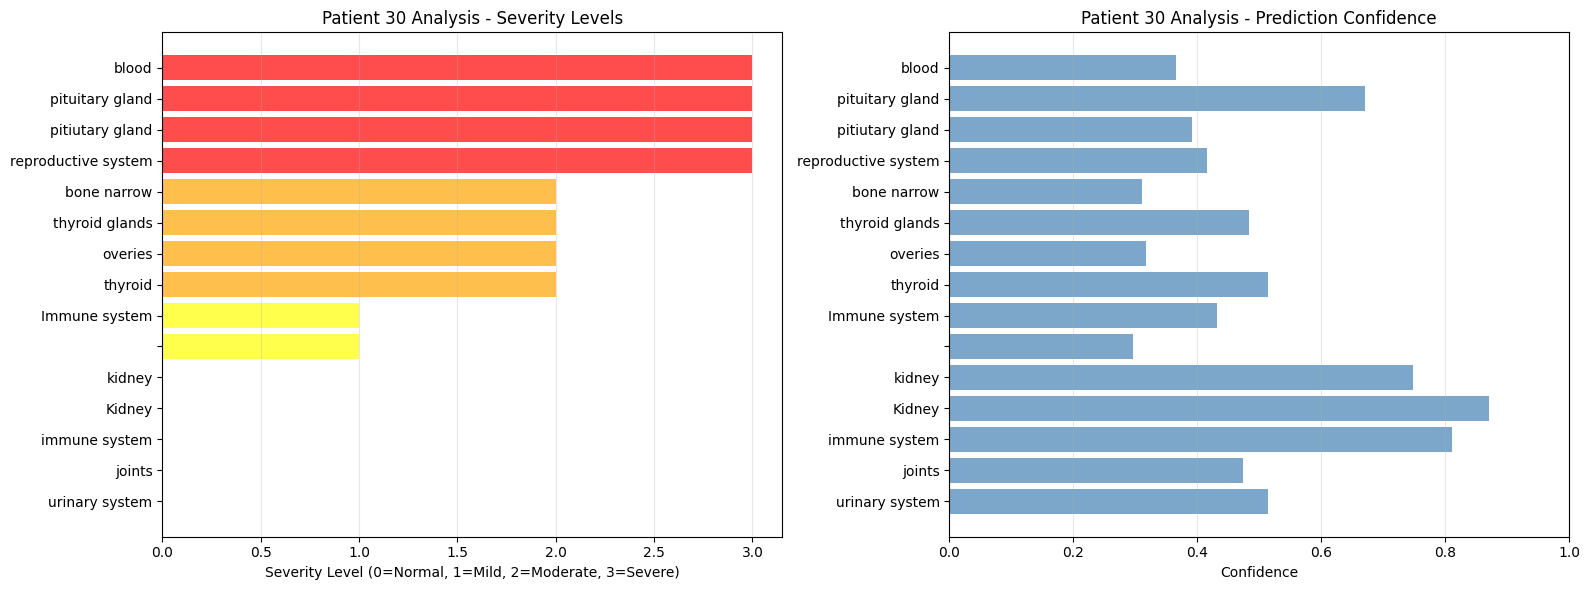

In [150]:
# Example: Visualize predictions for a patient
visualize_organ_predictions(prediction, title=f"Patient {PATIENT_INDEX} Analysis")

In [151]:
# Example: Compare multiple patients
# Get predictions for first 3 patients
comparison_predictions = []
comparison_labels = []

for i in range(3):
    pred = predict_patient(
        model=loaded_model,
        patient_idx=i,
        patient_feats=patient_feats,
        neighbors=neighs,
        organ_names=data_loader.organs,
        metapath_name=META_PATH  # Pass the metapath name
    )
    patient_info = get_patient_info(i, data_loader)
    
    comparison_predictions.append(pred)
    comparison_labels.append(f"Patient {patient_info['patient_id']}")

# Add new patient to comparison
comparison_predictions.append(new_patient_prediction)
comparison_labels.append("NEW_PATIENT")

# Compare all
compare_patients(comparison_predictions, comparison_labels)


📊 COMPARATIVE ANALYSIS: 4 PATIENTS

Patient                  Normal       Mild   Moderate     Severe   Avg Damage
----------------------------------------------------------------------------------------------------
Patient 139760         13 (68.4%)    3 (15.8%)    2 (10.5%)    1 ( 5.3%)     0.5523
Patient 214382         16 (84.2%)    3 (15.8%)    0 ( 0.0%)    0 ( 0.0%)     0.5177
Patient 214546         12 (63.2%)    1 ( 5.3%)    2 (10.5%)    4 (21.1%)     0.5605
NEW_PATIENT            16 (84.2%)    0 ( 0.0%)    1 ( 5.3%)    2 (10.5%)     0.5001


## 20. Export Predictions

Export predictions to CSV for further analysis or reporting.

In [152]:
def export_predictions_to_csv(predictions_list, patient_ids, output_path='../output/predictions.csv'):
    """
    Export predictions to CSV file.
    
    Args:
        predictions_list: list of prediction dicts
        patient_ids: list of patient IDs
        output_path: path to save CSV
    """
    rows = []
    
    for pred, patient_id in zip(predictions_list, patient_ids):
        for organ in pred['organ_predictions']:
            rows.append({
                'patient_id': patient_id,
                'organ': organ['organ'],
                'severity_level': organ['severity_level'],
                'severity_name': organ['severity_name'],
                'confidence': organ['confidence'],
                'damage_score': organ['damage_score'],
                'prob_normal': organ['severity_probs']['Normal'],
                'prob_mild': organ['severity_probs']['Mild'],
                'prob_moderate': organ['severity_probs']['Moderate'],
                'prob_severe': organ['severity_probs']['Severe']
            })
    
    df = pd.DataFrame(rows)
    df.to_csv(output_path, index=False)
    print(f"✅ Predictions exported to: {output_path}")
    print(f"   Total rows: {len(df)}")
    print(f"   Patients: {len(predictions_list)}")
    print(f"   Organs per patient: {len(df) // len(predictions_list)}")
    
    return df


# Example: Export predictions
predictions_to_export = []
patient_ids_to_export = []

# Get predictions for first 10 patients
for i in range(min(10, len(data_loader.patient_ids))):
    pred = predict_patient(
        model=loaded_model,
        patient_idx=i,
        patient_feats=patient_feats,
        neighbors=neighs,
        organ_names=data_loader.organs,
        metapath_name=META_PATH  # Pass the metapath name
    )
    patient_info = get_patient_info(i, data_loader)
    
    predictions_to_export.append(pred)
    patient_ids_to_export.append(patient_info['patient_id'])

# Export to CSV
exported_df = export_predictions_to_csv(
    predictions_to_export, 
    patient_ids_to_export,
    output_path='/Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation/output/test_predictions.csv'
)

# Show sample
print("\n📄 Sample of exported data:")
display(exported_df.head(15))

✅ Predictions exported to: /Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation/output/test_predictions.csv
   Total rows: 190
   Patients: 10
   Organs per patient: 19

📄 Sample of exported data:


,patient_id,organ,severity_level,severity_name,confidence,damage_score,prob_normal,prob_mild,prob_moderate,prob_severe
0,139760,,0,Normal,0.424247,0.345469,0.424247,0.136488,0.088379,0.350886
1,139760,Immune system,1,Mild,0.516642,0.659770,0.157024,0.516642,0.203002,0.123332
2,139760,Kidney,0,Normal,0.995624,0.688757,0.995624,0.000510,0.000449,0.003418
3,139760,blood,0,Normal,0.639165,0.602990,0.639165,0.009961,0.267603,0.083271
4,139760,bone narrow,2,Moderate,0.288485,0.814999,0.208754,0.223306,0.288485,0.279455
5,139760,cardiovascular system,0,Normal,0.756985,0.598484,0.756985,0.014705,0.119196,0.109114
6,139760,immune system,0,Normal,0.986895,0.652098,0.986895,0.002031,0.000847,0.010227
7,139760,joints,0,Normal,0.539487,0.479884,0.539487,0.068897,0.019022,0.372593
8,139760,kidney,3,Severe,0.923638,0.571297,0.007855,0.005836,0.062672,0.923638
9,139760,liver,1,Mild,0.785379,0.637594,0.139431,0.785379,0.068608,0.006582


## 🎯 Summary: How to Use This Testing Interface

### 1️⃣ Load a Trained Model
```python
MODEL_TYPE = 'hanpp'      # or 'hgthan'
META_PATH = 'P-O-P'       # or 'P-D-P', 'P-S-P'
# Run cells in Section 14
```

### 2️⃣ Test on Existing Patients
```python
PATIENT_INDEX = 0  # Change index to test different patients
# Run cells in Section 16
```

### 3️⃣ Test on New Patients
```python
new_patient_tests = {
    'Hemoglobin': 10.5,
    'WBC': 12000,
    'Glucose': 180,
    # ... add more test results
}
# Run cells in Section 17
```

### 4️⃣ Analyze and Compare
- Visualize predictions with bar charts
- Compare multiple patients side-by-side
- Export results to CSV for reporting

### 5️⃣ Interpret Results
- **Green (✅)**: Normal organ function
- **Yellow (🟡)**: Mild issues - monitor
- **Orange (🟠)**: Moderate issues - attention needed
- **Red (🔴)**: Severe issues - immediate attention required

**Confidence Score**: Higher = more certain about the prediction
**Damage Score**: Continuous value indicating organ damage severity